In [1]:
from julia.api import Julia
from julia import Main

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm
from multiprocessing import Pool
from concurrent.futures import ProcessPoolExecutor
import concurrent.futures

import scipy.special as sp
import os

import pathlib
from pathlib import Path
import json

#fitters

import pybobyqa
import time
import cma
import csv

def to_float64(df):
    num_cols = df.select_dtypes(include=["number"]).columns
    df[num_cols] = df[num_cols].astype("float64")
    return df

Which Fit?

In [2]:
fit_name = "Final"
approximate_total_xsec = True
data_uncertainty_only = False
total_eval_budget = 30000

Read Files

In [3]:
from pathlib import Path

TMD_fitting_root = "../"
def include(name):
    path = os.path.join(TMD_fitting_root, name)
    Main.eval(f'include(raw"{path}")')

include(f"Cards/{fit_name}.jl")
include(f"DY/DY_table_{Main.flavor_scheme}.jl")

# Data
file_root = f"../Data/{Main.data_name}/Cutted/DY"
matrix_root = f"../Data/{Main.data_name}/Covariance_Matrices/DY"
table_root = f"../Tables/{Main.table_name}/DY"
total_root = f"../Data/DY_total_xsec/{Main.pdf_name}"
error_sets_root = f"../Data/PDF_Matrices/{Main.error_sets_name}/DY"
chi2_root = Path("../Data/Chi2_Matrix")

initial_params = Main.initial_params


By file or by experiment?

In [4]:
data_selections = "by_experiment"  # "by_file" or "by_experiment"

In [5]:
experiments =[
    'ATLAS_7',
    'ATLAS_8', 
    #'ATLAS_13', 
    'CDF_I',
    'CDF_II',
    'CMS_7',
    'CMS_8',
    'CMS_13',    
    'D0_I',
    'D0_II',
    'D0_II_mu',
    'E288',
    'E605',
    'E772',
    'LHCb_7',
    'LHCb_8',
    'LHCb_13',    
    #'PHENIX',
    'STAR'
]



#["E288","E605","E772","ATLAS", "CMS", "D0", "CDF", "LHCb", "PHENIX", "STAR"]

if data_selections == "by_file":
    file_names = [

    #----------------------------------------------------------------------------
    # ATLAS
    #----------------------------------------------------------------------------

    #"ATLAS/ATLAS_7TeV_y_0_1.csv",
    #"ATLAS/ATLAS_7TeV_y_1_2.csv",
    #"ATLAS/ATLAS_7TeV_y_2_2.4.csv",

    #"ATLAS/ATLAS_8TeV_Q_44_66.csv",
    #"ATLAS/ATLAS_8TeV_Q_116_150.csv",

    #"ATLAS/ATLAS_8TeV_y_0_0.4.csv"
    #"ATLAS/ATLAS_8TeV_y_0.4_0.8.csv"
    #"ATLAS/ATLAS_8TeV_y_0.8_1.2.csv"
    #"ATLAS/ATLAS_8TeV_y_1.2_1.6.csv",
    #"ATLAS/ATLAS_8TeV_y_1.6_2.csv",
    #"ATLAS/ATLAS_8TeV_y_2_2.4.csv",

    #----------------------------------------------------------------------------
    # CDF
    #----------------------------------------------------------------------------

    #"CDF/CDF_RunI.csv",
    #"CDF/CDF_RunII.csv",

    #----------------------------------------------------------------------------
    # CMS
    #----------------------------------------------------------------------------

    #"CMS/CMS_7TeV.csv",
    #"CMS/CMS_8TeV.csv",
    
    #"CMS/CMS_13TeV_y_0_0.4.csv",
    #"CMS/CMS_13TeV_y_0.4_0.8.csv",
    #"CMS/CMS_13TeV_y_0.8_1.2.csv",
    #"CMS/CMS_13TeV_y_1.2_1.6.csv",
    #"CMS/CMS_13TeV_y_1.6_2.4.csv",

    #----------------------------------------------------------------------------
    # D0
    #----------------------------------------------------------------------------

    #"D0/D0_RunI.csv",
    #"D0/D0_RunII.csv",
    #"D0/D0_RunIImu.csv",

    #----------------------------------------------------------------------------
    # LHCb
    #----------------------------------------------------------------------------

    #"LHCb/LHCb_7TeV.csv",
    #"LHCb/LHCb_8TeV.csv",
    #"LHCb/LHCb_13TeV.csv",

    #----------------------------------------------------------------------------
    # Phenix
    #----------------------------------------------------------------------------

    #"PHENIX/PHENIX_200.csv",

    #----------------------------------------------------------------------------
    # STAR
    #----------------------------------------------------------------------------

    #"STAR/STAR_510.csv",

    #----------------------------------------------------------------------------
    # E288
    #----------------------------------------------------------------------------

    #"E288/E288_200_Q_4_5.csv",
    #"E288/E288_200_Q_5_6.csv",
    #"E288/E288_200_Q_6_7.csv",
    #"E288/E288_200_Q_7_8.csv",
    #"E288/E288_200_Q_8_9.csv",
    #"E288/E288_200_Q_10_11.csv",

    #"E288/E288_300_Q_4_5.csv",
    #"E288/E288_300_Q_5_6.csv",
    #"E288/E288_300_Q_6_7.csv",
    #"E288/E288_300_Q_7_8.csv",
    #"E288/E288_300_Q_8_9.csv",
    #"E288/E288_300_Q_10_11.csv",
    #"E288/E288_300_Q_11_12.csv",

    #"E288/E288_400_Q_5_6.csv",
    #"E288/E288_400_Q_6_7.csv",
    #"E288/E288_400_Q_7_8.csv",
    #"E288/E288_400_Q_8_9.csv",
    #"E288/E288_400_Q_10_11.csv",
    #"E288/E288_400_Q_11_12.csv",
    #"E288/E288_400_Q_12_13.csv",
    #"E288/E288_400_Q_13_14.csv",

    #----------------------------------------------------------------------------
    # E605
    #----------------------------------------------------------------------------

    #"E605/E605_Q_7_8.csv",
    #"E605/E605_Q_8_9.csv",
    #"E605/E605_Q_10.5_11.5.csv",
    #"E605/E605_Q_11.5_13.5.csv",
    #"E605/E605_Q_13.5_18.csv",

    #----------------------------------------------------------------------------
    # E772
    #----------------------------------------------------------------------------

    #"E772/E772_Q_5_6.csv",
    #"E772/E772_Q_6_7.csv",
    #"E772/E772_Q_7_8.csv",
    #"E772/E772_Q_8_9.csv",
    #"E772/E772_Q_11_12.csv",
    #"E772/E772_Q_12_13.csv",
    #"E772/E772_Q_13_14.csv",
    #"E772/E772_Q_14_15.csv",
    ]

In [6]:
from pathlib import Path

file_excludes = [
    "E772/E772-5Q6.csv",
    "E772/E772-6Q7.csv",
    "E772/E772-7Q8.csv",
    "E772/E772-8Q9.csv",
]

if data_selections == "by_experiment":
    file_names = []
    for experiment in experiments:
        exp_dir = Path(file_root) / experiment
        for p in sorted(exp_dir.glob("*.csv")):
            if str(experiment + "/" + p.name) in file_excludes:
                continue
            rel_path = Path(experiment, p.name).as_posix()
            file_names.append(rel_path)

display(file_names)

['ATLAS_7/ATLAS7-00y10.csv',
 'ATLAS_7/ATLAS7-10y20.csv',
 'ATLAS_7/ATLAS7-20y24.csv',
 'ATLAS_8/ATLAS8-00y04.csv',
 'ATLAS_8/ATLAS8-04y08.csv',
 'ATLAS_8/ATLAS8-08y12.csv',
 'ATLAS_8/ATLAS8-116Q150.csv',
 'ATLAS_8/ATLAS8-12y16.csv',
 'ATLAS_8/ATLAS8-16y20.csv',
 'ATLAS_8/ATLAS8-20y24.csv',
 'ATLAS_8/ATLAS8-46Q66.csv',
 'CDF_I/CDF1.csv',
 'CDF_II/CDF2.csv',
 'CMS_7/CMS7.csv',
 'CMS_8/CMS8.csv',
 'CMS_13/CMS13-00y04.csv',
 'CMS_13/CMS13-04y08.csv',
 'CMS_13/CMS13-08y12.csv',
 'CMS_13/CMS13-106Q170.csv',
 'CMS_13/CMS13-12y16.csv',
 'CMS_13/CMS13-16y24.csv',
 'CMS_13/CMS13-170Q350.csv',
 'CMS_13/CMS13-350Q1000.csv',
 'D0_I/D01.csv',
 'D0_II/D02.csv',
 'D0_II_mu/D02mu.csv',
 'E288/E228-200-4Q5.csv',
 'E288/E228-200-5Q6.csv',
 'E288/E228-200-6Q7.csv',
 'E288/E228-200-7Q8.csv',
 'E288/E228-200-8Q9.csv',
 'E288/E228-300-11Q12.csv',
 'E288/E228-300-4Q5.csv',
 'E288/E228-300-5Q6.csv',
 'E288/E228-300-6Q7.csv',
 'E288/E228-300-7Q8.csv',
 'E288/E228-300-8Q9.csv',
 'E288/E228-400-11Q12.csv',
 'E28

Read Data

In [7]:
data_list = dict()
matrix_data_list = dict()
matrix_total_list = dict()
df_total_xsec = to_float64(pd.read_csv(f"{total_root}.csv"))
total_xsec_names = df_total_xsec['name'].tolist()

for file in tqdm(file_names):

    df_data = to_float64(pd.read_csv(f"{file_root}/{file}"))
    data_list[file] = df_data
    
    matrix_data = to_float64(pd.read_csv(f"{matrix_root}/{file}"))
    
    if data_uncertainty_only == True:
        matrix_total = matrix_data
    else:
        matrix_PDF = to_float64(pd.read_csv(f"{error_sets_root}/{file}"))
        matrix_total = matrix_data + matrix_PDF
    
    matrix_data_list[file] = matrix_data
    matrix_total_list[file] = matrix_total

    name_short = Path(file).stem
    if name_short in total_xsec_names:
        total_xsec = df_total_xsec[df_total_xsec['name'] == name_short]["total_xsec"].values[0]
        data_list[file]['total_xsec'] = total_xsec*np.ones(len(data_list[file]))
        print(f"{name_short}'s total xsec = {total_xsec} added")

chi2_index_df = pd.read_csv(chi2_root / "Index.csv")
chi2_index_df["file"] = chi2_index_df["file"].astype(str).str.replace('\\', '/', regex=False)
required_cols = {"global_index", "file", "local_index"}
missing_cols = required_cols - set(chi2_index_df.columns)
if missing_cols:
    raise ValueError(f"Index.csv is missing required columns: {sorted(missing_cols)}")

chi2_index_df = chi2_index_df.sort_values("global_index").reset_index(drop=True)
expected_global = np.arange(len(chi2_index_df), dtype=int)
actual_global = chi2_index_df["global_index"].to_numpy(dtype=int)
if not np.array_equal(actual_global, expected_global):
    raise ValueError("Index.csv global_index must be contiguous and start at 0.")

file_set = set(file_names)
index_file_set = set(chi2_index_df["file"].unique())
missing_from_index = sorted(file_set - index_file_set)
extra_in_index = sorted(index_file_set - file_set)
if missing_from_index:
    raise ValueError(f"Index.csv is missing active fit files: {missing_from_index}")
if extra_in_index:
    raise ValueError(f"Index.csv contains files not used by this fit: {extra_in_index}")

chi2_file_positions = {}
chi2_file_local_indices = {}
for file, group in chi2_index_df.groupby("file", sort=False):
    chi2_file_positions[file] = group["global_index"].to_numpy(dtype=int)
    chi2_file_local_indices[file] = group["local_index"].to_numpy(dtype=int)
    file_len = len(data_list[file])
    if np.any(chi2_file_local_indices[file] < 0) or np.any(chi2_file_local_indices[file] >= file_len):
        raise IndexError(f"Index.csv local_index out of bounds for {file}")

Total_inverse = to_float64(pd.read_csv(chi2_root / "Total_inverse.csv")).to_numpy(dtype=float)
if Total_inverse.shape != (len(chi2_index_df), len(chi2_index_df)):
    raise ValueError(
        f"Total_inverse.csv shape {Total_inverse.shape} does not match Index.csv length {len(chi2_index_df)}"
    )
Total_inverse = 0.5 * (Total_inverse + Total_inverse.T)


 25%|██▍       | 14/57 [00:00<00:00, 135.78it/s]

ATLAS7-00y10's total xsec = 1.0 added
ATLAS7-10y20's total xsec = 1.0 added
ATLAS7-20y24's total xsec = 1.0 added
CMS7's total xsec = 1.0 added
CMS8's total xsec = 1.0 added


 74%|███████▎  | 42/57 [00:00<00:00, 121.50it/s]

D02's total xsec = 1.0 added
D02mu's total xsec = 1.0 added


100%|██████████| 57/57 [00:00<00:00, 117.43it/s]


Prediction

In [8]:
Params = Main.Params_Struct(*[np.float32(x) for x in initial_params]) 
#Main.set_params(Main.VRAM, Params) 

for i in range(10):
    Params = Main.Params_Struct(*[np.float32(x) for x in initial_params])                  
    predictions,t = Main.xsec_dict(Main.rel_paths, Main.VRAM)
    print(round(t*1000,2), "ms")

307.46 ms
37.24 ms
37.59 ms
37.23 ms
41.75 ms
38.23 ms
37.59 ms
37.91 ms
37.2 ms
37.32 ms


In [9]:
def get_file_length():

    file_lengths = dict()

    for file in file_names:

        df = to_float64(pd.read_csv(f"{file_root}/{file}"))

        file_lengths[file] = len(df)

    return file_lengths

file_lengths = get_file_length()

In [10]:
def _norm(p: str) -> str:
    return os.path.normpath(p).replace('\\', '/')

df_total_xsec = to_float64(pd.read_csv(f"{total_root}.csv"))
total_xsec_names = df_total_xsec['name'].tolist()

def prediction_reformat(predictions):
    preds = {_norm(k): v for k, v in predictions.items()}  # normalize keys once
    df_predictions = {}

    for file in file_names:
        n = file_lengths[file]
        base = os.path.splitext(file)[0]
        xs = []
        for i in range(n):
            table_path = _norm(os.path.join(table_root, f"{base}/{i}.jls"))
            xs.append(preds[table_path])
        xs = np.asarray(xs, dtype=float)
        df_predictions[file] = xs.copy()

        if approximate_total_xsec == True and Path(file).stem in total_xsec_names:
            data_xsec = data_list[file]["xsec"].to_numpy(dtype=float)
            qT_bin_size = (
                data_list[file]["qT_max"].to_numpy(dtype=float)
                - data_list[file]["qT_min"].to_numpy(dtype=float)
            )
            weighted_data = np.sum(data_xsec * qT_bin_size)
            weighted_theory = np.sum(xs * qT_bin_size)
            dσ = weighted_data / weighted_theory
            df_predictions[file] = dσ * xs
            #display(file, 1/dσ)

    return df_predictions

df_predictions = prediction_reformat(predictions)

Chi2

In [11]:
ASWZ_b_array = np.linspace(0.12,0.78,12)*5.067731
ASWZ_prediction = np.array([
    -0.08158508158508182,
    -0.1701631701631705,
    -0.2400932400932403,
    -0.34265734265734293,
    -0.37062937062937085,
    -0.4265734265734267,
    -0.4498834498834501,
    -0.44522144522144536,
    -0.4965034965034967,
    -0.5710955710955714,
    -0.6363636363636365,
    -0.7016317016317017
    ])
ASWZ_upper = np.array([
    0.18414918414918402,
    0.11421911421911402,
    0.09557109557109533,
    0.002331002331002141,
    0.016317016317016098,
    -0.034965034965035224,
    -0.034965034965035224,
    -0.011655011655011815,
    -0.034965034965035224,
    -0.05361305361305391,
    -0.05827505827505863,
    -0.04895104895104918
    ])
ASWZ_error = np.array(ASWZ_upper) - np.array(ASWZ_prediction)

def chi2_lattice(): 
    CS_list = []
    for b in ASWZ_b_array :
        Q = 2.0
        CS = Main.CS_total_func(b, Q)
        CS_list.append(CS)
    chi2dN = np.sum( (CS_list - ASWZ_prediction)**2 / ASWZ_error**2 ) / len(ASWZ_b_array)
    return chi2dN

def timed(func):
    t0 = time.perf_counter()
    out = func()
    return out, time.perf_counter() - t0

#chi2dN, t = timed(chi2_lattice)
#print("χ^2/N from LATTICE =", chi2dN, ", took", round(t, 4), "seconds")

In [12]:
def _coerce_index_df(index_source):
    if isinstance(index_source, (str, os.PathLike, Path)):
        index_df = pd.read_csv(index_source)
    else:
        index_df = index_source.copy()

    index_df = index_df.sort_values("global_index").reset_index(drop=True)
    return index_df


def build_indexed_column_vector(index_source, arrays_by_file):
    index_df = _coerce_index_df(index_source)
    vector = np.full((len(index_df), 1), np.nan, dtype=float)

    for file, group in index_df.groupby("file", sort=False):
        if file not in arrays_by_file:
            raise KeyError(f"Missing values for {file} in arrays_by_file")

        values = np.asarray(arrays_by_file[file], dtype=float).reshape(-1)
        local_indices = group["local_index"].to_numpy(dtype=int)
        if np.any(local_indices < 0) or np.any(local_indices >= len(values)):
            raise IndexError(f"Indexed local positions are out of bounds for {file}")

        global_indices = group["global_index"].to_numpy(dtype=int)
        vector[global_indices, 0] = values[local_indices]

    if np.isnan(vector).any():
        raise ValueError("Indexed column vector has unfilled entries. Check Index.csv coverage.")

    return vector


def get_prediction_column_vector(index_source, df_predictions):
    return build_indexed_column_vector(index_source, df_predictions)


def get_data_column_vector(index_source):
    arrays_by_file = {
        file: data_list[file]["xsec"].to_numpy(dtype=float)
        for file in file_names
    }
    return build_indexed_column_vector(index_source, arrays_by_file)


data_vector = get_data_column_vector(chi2_index_df)


def get_chi2dN(df_predictions):

    N_list = dict()
    chi2dN_list = dict()

    prediction_vector = get_prediction_column_vector(chi2_index_df, df_predictions)
    diff_vector = data_vector - prediction_vector
    weighted_diff = Total_inverse @ diff_vector

    chi2_total = float((diff_vector.T @ weighted_diff)[0, 0])
    N_total = int(diff_vector.shape[0])

    # With a full inverse covariance, these are additive row contributions,
    # not standalone per-file block chi2 values.
    point_contributions = diff_vector[:, 0] * weighted_diff[:, 0]

    for file in file_names:
        positions = chi2_file_positions[file]
        N = len(positions)
        chi2_file = float(np.sum(point_contributions[positions]))
        chi2dN_list[file] = float(round(chi2_file / N, 3))
        N_list[file] = N

    chi2dN = chi2_total / N_total
    return chi2dN, chi2dN_list, N_list

chi2dN, chi2dN_list, N_list = get_chi2dN(df_predictions)

print(f"Total chi^2/N = {chi2dN:.3f}")
display(chi2dN_list)


Total chi^2/N = 1.120


{'ATLAS_7/ATLAS7-00y10.csv': 4.378,
 'ATLAS_7/ATLAS7-10y20.csv': 5.795,
 'ATLAS_7/ATLAS7-20y24.csv': 1.304,
 'ATLAS_8/ATLAS8-00y04.csv': 3.79,
 'ATLAS_8/ATLAS8-04y08.csv': 0.226,
 'ATLAS_8/ATLAS8-08y12.csv': 1.221,
 'ATLAS_8/ATLAS8-116Q150.csv': 0.674,
 'ATLAS_8/ATLAS8-12y16.csv': 3.169,
 'ATLAS_8/ATLAS8-16y20.csv': 0.84,
 'ATLAS_8/ATLAS8-20y24.csv': 1.442,
 'ATLAS_8/ATLAS8-46Q66.csv': 2.303,
 'CDF_I/CDF1.csv': 0.637,
 'CDF_II/CDF2.csv': 1.407,
 'CMS_7/CMS7.csv': 1.414,
 'CMS_8/CMS8.csv': 0.753,
 'CMS_13/CMS13-00y04.csv': 1.678,
 'CMS_13/CMS13-04y08.csv': 0.95,
 'CMS_13/CMS13-08y12.csv': 0.464,
 'CMS_13/CMS13-106Q170.csv': 2.993,
 'CMS_13/CMS13-12y16.csv': 0.225,
 'CMS_13/CMS13-16y24.csv': 0.227,
 'CMS_13/CMS13-170Q350.csv': 1.631,
 'CMS_13/CMS13-350Q1000.csv': 1.717,
 'D0_I/D01.csv': 0.538,
 'D0_II/D02.csv': 1.124,
 'D0_II_mu/D02mu.csv': 0.493,
 'E288/E228-200-4Q5.csv': 0.378,
 'E288/E228-200-5Q6.csv': 0.234,
 'E288/E228-200-6Q7.csv': 0.314,
 'E288/E228-200-7Q8.csv': 0.223,
 'E288/E22

Objective

In [13]:
def objective(params):
    try:
        params_cl = Main.Params_Struct(*[np.float32(x) for x in params])
        Main.set_params(Main.VRAM, params_cl)

        predictions, t = Main.xsec_dict(Main.rel_paths, Main.VRAM)

        df_predictions = prediction_reformat(predictions)
        chi2dN, _, _ = get_chi2dN(df_predictions)

        if not np.isfinite(chi2dN): 
            return 1e5
        return chi2dN

    except Exception as e:
        return 1e5

print(objective(initial_params))

# freeze parameters

initial_params = np.asarray(initial_params, float)
frozen_idx = np.asarray(Main.frozen_indices, int)

dim_full = len(initial_params)
mask = np.ones(dim_full, dtype=bool)
mask[frozen_idx] = False
free_idx = np.where(mask)[0]   # indices that WILL be fitted

frozen_vals = initial_params[frozen_idx].copy()

def objective_with_freeze(params_free):

    params_free = np.asarray(params_free, float)
    full = initial_params.copy()
    full[free_idx] = params_free
    full[frozen_idx] = frozen_vals
    return objective(full)

print(objective_with_freeze(initial_params[free_idx]))

1.119777770315805
1.1197753136288808


Bounds

In [14]:
bounds_raw = np.asarray(Main.bounds_raw, float)[free_idx]

lower_bounds, upper_bounds = np.array(list(zip(*bounds_raw)))

def objective_normalized(params):

    normalized_params = lower_bounds + params * (upper_bounds - lower_bounds)

    return objective_with_freeze(normalized_params)

def objective_log(params):
    return np.log10(objective_normalized(params))

def normalize_params(params):
    return (params - lower_bounds) / (upper_bounds - lower_bounds)

def denormalize_params(params):
    return lower_bounds + params * (upper_bounds - lower_bounds)

theta0 = normalize_params(np.array(initial_params)[free_idx])
dim = len(bounds_raw)

Setting 1 (1.501)

In [15]:
long_fit = False

if long_fit == True:

    import time
    import cma

    def make_progress_objective(f, delta=1e-3, alive_every_min=5):
        state = {
            "best": np.inf,   # best log10(chi2)
            "xbest": None,    # best params
            "nevals": 0,
            "t0": time.time(),
            "last_alive": time.time(),
        }

        def wrapped(x):
            val = f(x)
            state["nevals"] += 1

            now = time.time()
            minutes = (now - state["t0"]) / 60.0

            # print only when improved by at least delta in log-space
            if state["best"] - val >= delta:
                state["best"] = val
                state["xbest"] = np.array(x, copy=True)

                x_str = np.array2string(state["xbest"], precision=7, separator=", ")
                print(
                    f"[CMA-ES] eval {state['nevals']}: "
                    f"new best χ² = {10**val:.3f}, "
                    f"params = {x_str}, "
                    f"t = {minutes:.0f} min"
                )
                state["last_alive"] = now

            # heartbeat every N minutes even without improvement
            if (now - state["last_alive"]) / 60.0 >= alive_every_min:
                print(f"[CMA-ES] alive @ {minutes:.1f} min (eval {state['nevals']})")
                state["last_alive"] = now

            return val

        wrapped.state = state
        return wrapped

    # Wrap your log-chi2 objective
    objective_with_progress = make_progress_objective(objective_log, delta=1e-3)

    dim = len(theta0)

    res = cma.fmin(
        objective_with_progress,
        theta0,          # assumed scaled to [0,1]^dim
        0.3,             # wider start to help global search
        {
            "bounds": [0.0, 1.0],
            "maxfevals": 500000,
            "popsize": 8 + int(4 * np.log(dim)),  # larger than default for more exploration
            "CMA_active": True,
            "CMA_elitist": True,
            "CMA_diagonal": 50,   # first 50 iters diagonal-only for robust global-ish search
            "verb_disp": 0,       # silence built-in logs; we use our own
        },
        restarts=8,
        incpopsize=2,
    )

    optimal_params = denormalize_params(res.x)
    rounded = [float(f"{x:.{3}g}") for x in optimal_params]
    print(rounded)

Setting 2

Global Minimize

Py-Bobyqa Fit

In [ ]:
from types import SimpleNamespace

use_random_seed = False
fit_seed = 0
fit_rng = np.random.default_rng() if use_random_seed else np.random.default_rng(fit_seed)

if int(total_eval_budget) < 300:
    raise ValueError("total_eval_budget must be at least 300 for the staged Py-BOBYQA fit.")

total_eval_budget = int(total_eval_budget)
randomize_start = total_eval_budget >= 900
alpha = 4.0 if total_eval_budget >= 1800 else 5.5

prescan_budget = int(np.clip(8 + 0.45 * np.sqrt(total_eval_budget), 8, 120))
extra_prescan = max(0, prescan_budget - 3)
exploration_beta_samples = int(round(0.75 * extra_prescan))
exploration_uniform_samples = int(extra_prescan - exploration_beta_samples)

main_budget = total_eval_budget - prescan_budget
rescue_fraction = 0.35 if total_eval_budget >= 2500 else (0.30 if total_eval_budget >= 1200 else 0.25)
rescue_budget_pool = int(main_budget * rescue_fraction)
local_budget_pool = main_budget - rescue_budget_pool

max_initial_starts = int(np.clip(2 + 0.05 * np.sqrt(max(local_budget_pool, 1)), 2, 10))
max_rescue_starts = int(np.clip(1 + 0.05 * np.sqrt(max(rescue_budget_pool, 1)), 1, 6))

local_budget_per_start = max(80, local_budget_pool // max_initial_starts)
local_stage1_maxfun = max(50, int(round(local_budget_per_start * 0.65)))
local_stage2_maxfun = max(25, local_budget_per_start - local_stage1_maxfun)

rescue_budget_per_start = max(70, rescue_budget_pool // max_rescue_starts)
rescue_stage1_maxfun = max(45, int(round(rescue_budget_per_start * 0.65)))
rescue_stage2_maxfun = max(25, rescue_budget_per_start - rescue_stage1_maxfun)

local_stage1_rhobeg = 0.10
local_stage1_rhoend = 1e-4
local_stage2_rhobeg = 0.04
local_stage2_rhoend = 1e-6

rescue_stage1_rhobeg = 0.14
rescue_stage1_rhoend = 5e-4
rescue_stage2_rhobeg = 0.05
rescue_stage2_rhoend = 1e-6

base_jitter_sigma = 0.10 if total_eval_budget >= 1600 else 0.08
previous_jitter_sigma = 0.06 if total_eval_budget >= 1600 else 0.05
rescue_jitter_sigma = 0.08 if total_eval_budget >= 1600 else 0.06

rescue_enabled = True
rescue_chi2dN_threshold = 1.45 if total_eval_budget >= 1600 else 1.55

results_path = Path("results") / "results.csv"
results_path.parent.mkdir(parents=True, exist_ok=True)

fit_state = {"evals_used": 0}

def remaining_budget():
    return total_eval_budget - int(fit_state["evals_used"])

def objective_log_budgeted(params):
    if remaining_budget() <= 0:
        raise RuntimeError("Evaluation budget exhausted.")
    fit_state["evals_used"] += 1
    return objective_log(params)

def draw_theta0(rng):
    if not randomize_start:
        return theta0.copy()

    while True:
        if remaining_budget() <= 0:
            return theta0.copy()
        cand = rng.beta(alpha, alpha, size=dim)
        val = float(objective_log_budgeted(cand))
        if np.isfinite(val) and val < 1.0:
            return cand

def draw_uniform_theta(rng):
    return rng.uniform(0.0, 1.0, size=dim)

def jitter_theta(theta, sigma, rng):
    return np.clip(theta + rng.normal(scale=sigma, size=dim), 0.0, 1.0)

def dedupe_theta_starts(starts, atol=1e-10):
    unique = []
    for theta in starts:
        if theta is None:
            continue
        if not any(np.allclose(theta, prev, atol=atol, rtol=0.0) for prev in unique):
            unique.append(theta.copy())
    return unique

def score_theta(theta):
    try:
        val = float(objective_log_budgeted(theta))
    except Exception:
        val = np.inf
    return val

def build_fit_starts(rng):
    base_theta = theta0.copy()
    candidate_starts = [
        base_theta,
        jitter_theta(base_theta, base_jitter_sigma, rng),
        jitter_theta(base_theta, previous_jitter_sigma, rng),
    ]

    for _ in range(exploration_beta_samples):
        candidate_starts.append(draw_theta0(rng))

    for _ in range(exploration_uniform_samples):
        candidate_starts.append(draw_uniform_theta(rng))

    unique_starts = dedupe_theta_starts(candidate_starts)
    scored = []
    for theta in unique_starts:
        if remaining_budget() <= 0:
            break
        val = score_theta(theta)
        if np.isfinite(val):
            scored.append((val, theta.copy()))

    if not scored:
        fallback_theta = theta0.copy()
        return [(fallback_theta, np.inf)], []

    scored.sort(key=lambda item: item[0])
    selected = [(theta.copy(), val) for val, theta in scored[:max_initial_starts]]
    return selected, scored

def fallback_result(theta_start, exc, fallback_fval=None):
    if fallback_fval is not None and np.isfinite(fallback_fval):
        fval = float(fallback_fval)
    elif remaining_budget() > 0:
        try:
            fval = float(objective_log_budgeted(theta_start))
        except Exception:
            fval = np.inf
    else:
        fval = np.inf

    return SimpleNamespace(
        x=np.clip(theta_start.copy(), 0.0, 1.0),
        f=fval,
        nf=0,
        flag=-999,
        message=str(exc),
    )

def solve_fit_stage(theta_start, *, maxfun, rhobeg, rhoend, seek_global_minimum, fallback_fval=None):
    maxfun = min(int(maxfun), remaining_budget())
    if maxfun <= 0:
        return fallback_result(theta_start, RuntimeError("No evaluation budget remaining for this stage."), fallback_fval=fallback_fval)

    try:
        return pybobyqa.solve(
            objective_log_budgeted,
            np.clip(theta_start, 0.0, 1.0),
            bounds=(np.zeros(dim), np.ones(dim)),
            maxfun=maxfun,
            rhobeg=rhobeg,
            rhoend=rhoend,
            scaling_within_bounds=True,
            seek_global_minimum=seek_global_minimum,
        )
    except Exception as exc:
        return fallback_result(theta_start, exc, fallback_fval=fallback_fval)

def better_result(res_a, res_b):
    if res_a is None:
        return res_b
    if res_b is None:
        return res_a
    return res_b if float(res_b.f) < float(res_a.f) else res_a

def run_local_track(theta_start, theta_start_score):
    res1 = solve_fit_stage(
        theta_start,
        maxfun=local_stage1_maxfun,
        rhobeg=local_stage1_rhobeg,
        rhoend=local_stage1_rhoend,
        seek_global_minimum=False,
        fallback_fval=theta_start_score,
    )
    res2 = solve_fit_stage(
        np.clip(res1.x, 0.0, 1.0),
        maxfun=local_stage2_maxfun,
        rhobeg=local_stage2_rhobeg,
        rhoend=local_stage2_rhoend,
        seek_global_minimum=False,
        fallback_fval=float(res1.f),
    )
    return better_result(res1, res2)

def run_rescue_track(theta_start, theta_start_score=None):
    res1 = solve_fit_stage(
        theta_start,
        maxfun=rescue_stage1_maxfun,
        rhobeg=rescue_stage1_rhobeg,
        rhoend=rescue_stage1_rhoend,
        seek_global_minimum=True,
        fallback_fval=theta_start_score,
    )
    res2 = solve_fit_stage(
        np.clip(res1.x, 0.0, 1.0),
        maxfun=rescue_stage2_maxfun,
        rhobeg=rescue_stage2_rhobeg,
        rhoend=rescue_stage2_rhoend,
        seek_global_minimum=False,
        fallback_fval=float(res1.f),
    )
    return better_result(res1, res2)

def run_pybobyqa_fit(rng):
    starts, start_scores = build_fit_starts(rng)
    best_res = None
    best_label = None
    local_candidates = []

    print(f"total_eval_budget = {total_eval_budget}")
    print(
        f"derived plan: prescan={prescan_budget}, local_starts={max_initial_starts}, "
        f"local_per_start={local_budget_per_start}, rescue_starts={max_rescue_starts}, "
        f"rescue_per_start={rescue_budget_per_start}"
    )
    print(f"prescan kept {len(starts)} starts out of {len(start_scores)} finite candidates.")
    print("best prescan log10(chi^2/N):", ", ".join(f"{val:.3f}" for val, _ in start_scores[:len(starts)]))

    for idx, (theta_start, theta_score) in enumerate(starts):
        if remaining_budget() <= 0:
            break
        trial_res = run_local_track(theta_start, theta_score)
        local_candidates.append((trial_res, f"local-{idx}"))
        if best_res is None or float(trial_res.f) < float(best_res.f):
            best_res = trial_res
            best_label = f"local-{idx}"

    if best_res is None:
        raise RuntimeError("Py-BOBYQA did not return any candidate result.")

    best_chi2dN_local = float(10 ** best_res.f) if np.isfinite(best_res.f) else np.inf
    should_run_rescue = rescue_enabled and remaining_budget() > 0 and (
        int(best_res.flag) != 0 or best_chi2dN_local > rescue_chi2dN_threshold
    )

    if should_run_rescue:
        local_candidates.sort(key=lambda item: float(item[0].f))
        rescue_seeds = [(np.clip(best_res.x, 0.0, 1.0), float(best_res.f))]
        for local_res, _ in local_candidates[:min(3, len(local_candidates))]:
            local_theta = np.clip(local_res.x, 0.0, 1.0)
            local_score = float(local_res.f)
            rescue_seeds.append((local_theta, local_score))
            rescue_seeds.append((jitter_theta(local_theta, rescue_jitter_sigma, rng), None))
        rescue_seeds.append((draw_uniform_theta(rng), None))

        deduped_rescue = []
        seen = []
        for theta_seed, theta_score in rescue_seeds:
            if any(np.allclose(theta_seed, prev, atol=1e-10, rtol=0.0) for prev in seen):
                continue
            seen.append(theta_seed.copy())
            deduped_rescue.append((theta_seed.copy(), theta_score))
        rescue_starts = deduped_rescue[:max_rescue_starts]

        for idx, (theta_start, theta_score) in enumerate(rescue_starts):
            if remaining_budget() <= 0:
                break
            trial_res = run_rescue_track(theta_start, theta_score)
            if float(trial_res.f) < float(best_res.f):
                best_res = trial_res
                best_label = f"rescue-{idx}"
    else:
        best_label = f"{best_label}|no-rescue"

    return best_res, best_label

res, best_label = run_pybobyqa_fit(fit_rng)
total_nfev = int(fit_state["evals_used"])

best_chi2dN = float(10 ** res.f) if np.isfinite(res.f) else np.inf
optimal_params_normalized = np.clip(np.asarray(res.x, dtype=float), 0.0, 1.0)
optimal_params = denormalize_params(optimal_params_normalized)

print(f"Best chi^2/N = {best_chi2dN:.3f}")
print(f"Track = {best_label}, evals_used = {int(total_nfev)} / {total_eval_budget}")
rounded = [float(f"{x:.3g}") for x in optimal_params]
print(rounded)

fmt = lambda x: f"{float(x):.3g}"
with results_path.open("a", newline="") as f:
    csv.writer(f).writerow([0, fmt(best_chi2dN), *map(fmt, np.asarray(optimal_params))])

Fit Results

In [ ]:
optimal_params_normalized = np.clip(np.asarray(res.x, dtype=float), 0.0, 1.0)
optimal_params = denormalize_params(optimal_params_normalized)
best_chi2dN = float(10 ** res.f) if np.isfinite(res.f) else np.inf
N_evals = int(total_nfev)

if int(res.flag) == 0:
    print("Optimization successful.")
else:
    print("Optimization ended without a clean convergence flag.")
    if hasattr(res, "message"):
        print("Message:", res.message)

print()
print("# of Evals =", N_evals)
print("Budget =", total_eval_budget)
print("Remaining budget =", total_eval_budget - N_evals)
print()
print("Track =", best_label)
print("Flag =", int(res.flag))
print()
print("Best chi^2/N =", round(best_chi2dN, 4) if np.isfinite(best_chi2dN) else best_chi2dN)
print()
print("Best parameters (normalized):")
print(", ".join(f"{x:.3g}" for x in optimal_params_normalized))
print()
print("Best parameters (unnormalized):")
print(", ".join(f"{x:.3g}" for x in optimal_params))


Optimization successful.

# of Evals = 7462
Budget = 30000
Remaining budget = 22538

Track = local-3|no-rescue
Flag = 0

Best chi^2/N = 1.1196

Best parameters (normalized):
0.495, 0.118, 0.401, 0.597, 0.362, 0.452, 0.26, 0.269, 0.124

Best parameters (unnormalized):
-0.00537, 0.961, -1.99, -4.43, 1.29, -0.29, 1.47, 0.0671, 0.0311


In [ ]:
full_params = initial_params.copy()
full_params[free_idx] = optimal_params          # optimal_params = free-only
full_params[frozen_idx] = frozen_vals           # keep frozen fixed
params_cl = Main.Params_Struct(*[np.float32(x) for x in full_params])
print(params_cl)

Main.set_params(Main.VRAM, params_cl)
predictions,t = Main.xsec_dict(Main.rel_paths, Main.VRAM)

df_predictions = prediction_reformat(predictions)
chi2dN, chi2dN_list, N_list = get_chi2dN(df_predictions)

df = pd.DataFrame.from_dict(chi2dN_list, orient="index", columns=["chi^2/N contribution"])
df["N"] = pd.Series(N_list)
df = df.reset_index().rename(columns={"index":"experiment"})
df["experiment"] = df["experiment"].apply(lambda s: Path(s).stem)
df = df[["experiment", "N", "chi^2/N contribution"]]

styled = (
    df.style
      .set_properties(**{"text-align": "center"})           
      .set_table_styles([{"selector": "th", "props": [("text-align", "center")]}])  
)
fmt = {col: "{:.2f}" for col in df.select_dtypes(include="float").columns}

total_N = int(df["N"].sum())
print("Total N:", total_N)
display(styled.format(fmt))


<PyCall.jlwrap Params_Struct(-0.0053707627f0, 0.961048f0, -1.9871736f0, -4.428957f0, 1.2885845f0, -0.28960368f0, 1.4675312f0, 0.06714335f0, 0.031065406f0)>
Total N: 465


,experiment,N,chi^2/N contribution
0,ATLAS7-00y10,6,4.24
1,ATLAS7-10y20,6,5.61
2,ATLAS7-20y24,6,1.25
3,ATLAS8-00y04,6,3.87
4,ATLAS8-04y08,6,0.27
5,ATLAS8-08y12,6,1.11
6,ATLAS8-116Q150,8,0.69
7,ATLAS8-12y16,6,3.12
8,ATLAS8-16y20,6,0.86
9,ATLAS8-20y24,6,1.52


Plots

In [ ]:
plots_list = dict([])

for file in file_names:

    df = pd.read_csv(f"{file_root}/{file}")

    qT_array = df["qT_mean"]
    data_array = df["xsec"]
    prediction_array = df_predictions[file]
    
    ratio_array = np.array(prediction_array)/df["xsec"]

    matrix_data = matrix_data_list[file]
    error_data_array = np.sqrt(np.diag(matrix_data))
    error_data_ratio_array = error_data_array/data_array

    matrix_total = matrix_total_list[file]
    error_total_array = np.sqrt(np.diag(matrix_total))
    error_total_ratio_array = error_total_array/data_array

    df_plot = pd.DataFrame([])

    df_plot["qT_array"] = qT_array
    df_plot["data_array"] = data_array
    df_plot["prediction_array"] = prediction_array
    df_plot["ratio_array"] = ratio_array
    df_plot["error_data_array"] = error_data_array
    df_plot["error_data_ratio_array"] = error_data_ratio_array
    df_plot["error_total_array"] = error_total_array
    df_plot["error_total_ratio_array"] = error_total_ratio_array

    plots_list[file] = df_plot

def fmt(x):  
    return f"{float(x):g}"

C:\Users\congyue zhang\AppData\Local\Temp\ipykernel_2416\3808722855.py:145: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


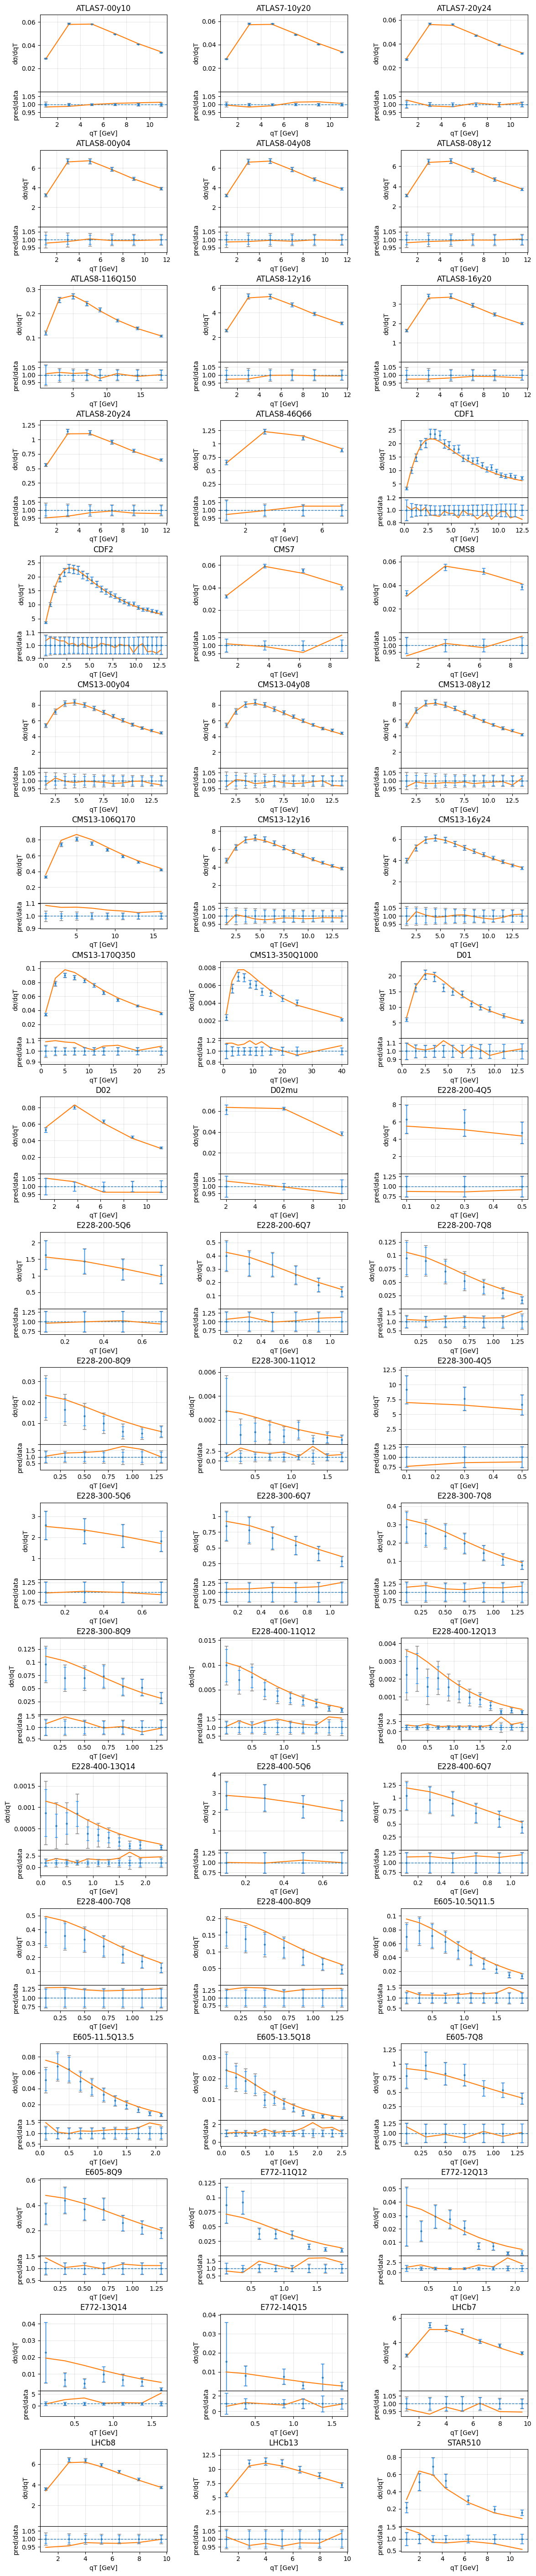

In [ ]:
# settings

data_color = "dodgerblue"
total_error_color = "gray"
prediction_color = 'tab:orange'

prediction_width = 1.5
fmt = "o"
fmt_size = 2

import math
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
from pathlib import Path

# Order to plot (or: sorted(file_names))
files_in_order = list(plots_list.keys())
max_cols_per_row = 3

n_files = len(files_in_order)
if n_files == 0:
    raise ValueError("No files to plot.")

ncols = min(max_cols_per_row, n_files)
nrow_pairs = math.ceil(n_files / ncols)

# Figure & outer grid (spacing BETWEEN files)
fig = plt.figure(figsize=(4.6 * ncols, 3.8 * nrow_pairs))
outer = fig.add_gridspec(nrows=nrow_pairs, ncols=ncols, wspace=0.42, hspace=0.32)

# Hide only the "0" tick label on the spectrum axis
hide_zero_label = FuncFormatter(lambda y, pos: "" if np.isclose(y, 0.0) else f"{y:g}")

def set_spectrum_ylim(ax, y_data, y_err, y_pred, pad_frac=0.12):
    """
    Bottom fixed at 0. Top = max(data+err, prediction) * (1 + pad_frac).
    Purely percentage-based (no fixed absolute padding).
    """
    y_data = np.asarray(y_data, float)
    y_err  = np.asarray(y_err,  float)
    y_pred = np.asarray(y_pred, float)

    data_up = y_data + np.nan_to_num(y_err, nan=0.0)
    candidates = np.concatenate([
        data_up[np.isfinite(data_up)],
        y_pred[np.isfinite(y_pred)]
    ])
    if candidates.size == 0:
        ax.set_ylim(0.0, 1.0)
        return

    ymax = float(np.max(candidates))
    if not np.isfinite(ymax) or ymax <= 0:
        ax.set_ylim(0.0, 1.0)
        return

    ax.set_ylim(0.0, np.nextafter(ymax * (1.0 + pad_frac), np.inf))

def set_ratio_ylim_symmetric_around_one(ax, ratio_vals, ratio_errs,
                                        margin_frac=0.22, min_half_frac=0.08):
    """
    Symmetric about y=1.0, covering ratio points AND 1±err, with percentage-based extra margin.
      - margin_frac: extra headroom as a fraction of the required half-span
      - min_half_frac: minimum half-span as a fraction of 1.0
    """
    r = np.asarray(ratio_vals, float)
    e = np.asarray(ratio_errs, float)
    r_finite = r[np.isfinite(r)]
    e_finite = e[np.isfinite(e)]

    if r_finite.size == 0 and e_finite.size == 0:
        half = max(min_half_frac, 0.10)
        ax.set_ylim(1.0 - half, 1.0 + half)
        return

    lower_from_points = np.min(r_finite) if r_finite.size else np.inf
    upper_from_points = np.max(r_finite) if r_finite.size else -np.inf

    if e_finite.size:
        max_err = float(np.nanmax(e_finite))
        lower_from_errors = 1.0 - max_err
        upper_from_errors = 1.0 + max_err
    else:
        lower_from_errors = np.inf
        upper_from_errors = -np.inf

    lower = min(lower_from_points, lower_from_errors)
    upper = max(upper_from_points, upper_from_errors)

    half_needed = max(1.0 - lower, upper - 1.0, 0.0)
    half = max(half_needed * (1.0 + margin_frac), min_half_frac)
    ax.set_ylim(1.0 - half, 1.0 + half)

for idx, fname in enumerate(files_in_order):
    r = idx // ncols
    c = idx % ncols

    # Inner grid per file: top+bottom, zero vertical gap; share x within the pair
    inner = outer[r, c].subgridspec(nrows=2, ncols=1, height_ratios=[3, 1], hspace=0.0)
    ax_top = fig.add_subplot(inner[0, 0])
    ax_bot = fig.add_subplot(inner[1, 0], sharex=ax_top)

    plot_df = plots_list[fname]
    qT              = plot_df["qT_array"].to_numpy()
    data_vals       = plot_df["data_array"].to_numpy()
    pred_vals       = np.asarray(plot_df["prediction_array"], float)
    data_err        = plot_df["error_data_array"].to_numpy()
    total_err       = plot_df["error_total_array"].to_numpy()
    ratio_vals      = plot_df["ratio_array"].to_numpy()
    ratio_err_data  = plot_df["error_data_ratio_array"].to_numpy()
    ratio_err_total = plot_df["error_total_ratio_array"].to_numpy()

    y_err_max = np.maximum(data_err, total_err)

    # --- Top: data ± errors vs prediction ---
    ax_top.errorbar(qT, data_vals, yerr=total_err, fmt='none', ecolor=total_error_color, elinewidth=1, capsize=3, label="total err")
    ax_top.errorbar(qT, data_vals, yerr=data_err, fmt=fmt, mfc='none',ms=fmt_size, elinewidth=1, capsize=2, label="data err", ecolor=data_color)
    ax_top.plot(qT, pred_vals, linewidth=prediction_width, label="prediction", color=prediction_color)
    ax_top.set_title(Path(fname).stem)
    ax_top.set_ylabel("dσ/dqT")
    ax_top.grid(True, alpha=0.3)
    set_spectrum_ylim(ax_top, data_vals, y_err_max, pred_vals)     # starts at 0, % headroom
    ax_top.yaxis.set_major_formatter(hide_zero_label)             # hide "0" label
    ax_top.tick_params(labelbottom=False)                         # no x labels on top panel
    # show the separator line between panels (keep both spines visible)
    ax_top.spines['bottom'].set_visible(True)
    #if idx == 0:
    #    ax_top.legend(frameon=False)

    ratio_err_max = np.maximum(ratio_err_data, ratio_err_total)

    # --- Bottom: ratio, symmetric about 1.0 with % margin ---
    ax_bot.axhline(1.0, linestyle="--", linewidth=1)
    ax_bot.plot(qT, ratio_vals, linewidth=prediction_width, color=prediction_color)
    ax_bot.errorbar(qT, np.ones_like(qT), yerr=ratio_err_total, fmt='none', ecolor=total_error_color, elinewidth=1, capsize=3)
    ax_bot.errorbar(qT, np.ones_like(qT), yerr=ratio_err_data, fmt=fmt, mfc='none', ecolor=data_color, elinewidth=1, capsize=2, ms=fmt_size)
    ax_bot.set_xlabel("qT [GeV]")
    ax_bot.set_ylabel("pred/data")
    ax_bot.grid(True, alpha=0.3)
    set_ratio_ylim_symmetric_around_one(ax_bot, ratio_vals, ratio_err_max,
                                        margin_frac=0.22, min_half_frac=0.08)
    ax_bot.spines['top'].set_visible(True)  # separator remains visible

plt.tight_layout()
plt.show()


Dimensional Reduction

In [ ]:
import numpy as np

def analyze_chi2_hessian_from_objective_log(
    objective_log,
    x,
    bounds=(0.0, 1.0),
    rel_step=1e-4,
    abs_step=1e-6,
    eps_rel_psd=1e-12,
    corr_thresholds=(0.90, 0.95, 0.98, 0.99),
    tau_keep=(1e-2, 1e-3, 1e-4),
    print_top_pairs=15,
    use_cache=True,
    verbose=True,
):
    """
    One-stop analysis for chi^2 fits when your objective is:
        objective_log(x) = log10(chi2(x))

    Input:
      - objective_log: callable f(x)-> float (log10 chi^2)
      - x: parameters in the SAME space objective_log expects (e.g. normalized [0,1]^n)
      - bounds: (lb, ub) scalars or arrays; used to keep FD steps legal
    Output dict contains:
      - f0, chi2
      - grad_log, H_log
      - H_chi2_raw, H_chi2_psd
      - Cov, Corr
      - eigenvalues/modes
      - suggested reduced-dimension bases Vr for multiple tau thresholds
    """

    x = np.asarray(x, dtype=float)
    n = x.size

    # ---- bounds ----
    lb, ub = bounds
    if np.isscalar(lb): lb = np.full(n, float(lb))
    if np.isscalar(ub): ub = np.full(n, float(ub))
    lb = np.asarray(lb, dtype=float)
    ub = np.asarray(ub, dtype=float)

    def clamp(z):
        z = np.asarray(z, dtype=float)
        return np.minimum(np.maximum(z, lb), ub)

    # ---- per-parameter step ----
    h = np.maximum(abs_step, rel_step * (np.abs(x) + 1.0))

    # try to keep central steps inside bounds when possible
    # but don't force h->0 (we'll do one-sided where needed)
    safety = 0.49
    max_h = safety * np.minimum(x - lb, ub - x)
    h = np.minimum(h, np.maximum(max_h, 0.0))

    # ---- eval with caching ----
    cache = {}
    nevals = 0

    def feval(z):
        nonlocal nevals
        z = clamp(z)
        if use_cache:
            key = z.tobytes()
            if key in cache:
                return cache[key]
        val = float(objective_log(z))
        nevals += 1
        if use_cache:
            cache[key] = val
        return val

    f0 = feval(x)
    chi2 = float(np.power(10.0, f0))
    ln10 = np.log(10.0)

    if verbose:
        x_str = np.array2string(x, precision=8, separator=", ")
        print("\n[Input check]")
        print("x =", x_str)
        print(f"log10(chi2) = {f0:.12g}")
        print(f"chi2       = {chi2:.12g}")

    # ---- choose direction per coordinate (central/forward/backward) ----
    def dir_for_i(i):
        # prefer central if possible
        if h[i] > 0 and (x[i] + h[i] <= ub[i]) and (x[i] - h[i] >= lb[i]):
            return 0  # central
        # else forward/backward if possible
        if x[i] + h[i] <= ub[i]:
            return +1
        if x[i] - h[i] >= lb[i]:
            return -1
        return 0  # pinned (should be rare)

    dirs = np.array([dir_for_i(i) for i in range(n)], dtype=int)

    # ---- precompute single steps ----
    f_p = np.full(n, np.nan)
    f_m = np.full(n, np.nan)

    for i in range(n):
        if h[i] == 0:
            continue
        if dirs[i] == 0:  # central
            xp = x.copy(); xp[i] += h[i]
            xm = x.copy(); xm[i] -= h[i]
            f_p[i] = feval(xp)
            f_m[i] = feval(xm)
        elif dirs[i] == +1:  # forward
            xp = x.copy(); xp[i] += h[i]
            f_p[i] = feval(xp)
        elif dirs[i] == -1:  # backward
            xm = x.copy(); xm[i] -= h[i]
            f_m[i] = feval(xm)

    # ---- gradient of log10(chi2) ----
    g = np.zeros(n, dtype=float)
    for i in range(n):
        if h[i] == 0:
            g[i] = 0.0
        elif dirs[i] == 0:
            g[i] = (f_p[i] - f_m[i]) / (2.0 * h[i])
        elif dirs[i] == +1:
            g[i] = (f_p[i] - f0) / h[i]
        else:  # -1
            g[i] = (f0 - f_m[i]) / h[i]

    # ---- Hessian of log10(chi2) ----
    H = np.zeros((n, n), dtype=float)

    # diagonal second derivatives
    for i in range(n):
        if h[i] == 0:
            H[i, i] = 0.0
            continue

        if dirs[i] == 0:
            H[i, i] = (f_p[i] - 2.0 * f0 + f_m[i]) / (h[i] ** 2)
        elif dirs[i] == +1:
            x2p = x.copy(); x2p[i] += 2.0 * h[i]
            f2p = feval(x2p)
            H[i, i] = (f2p - 2.0 * f_p[i] + f0) / (h[i] ** 2)
        else:  # -1
            x2m = x.copy(); x2m[i] -= 2.0 * h[i]
            f2m = feval(x2m)
            H[i, i] = (f0 - 2.0 * f_m[i] + f2m) / (h[i] ** 2)

    # mixed partials
    # - if both coords central -> use 2nd-order central mixed formula
    # - otherwise use 1st-order (forward/backward) mixed formula with available signs
    for i in range(n):
        for j in range(i + 1, n):
            if h[i] == 0 or h[j] == 0:
                Hij = 0.0
            elif dirs[i] == 0 and dirs[j] == 0:
                xpp = x.copy(); xpp[i] += h[i]; xpp[j] += h[j]
                xpm = x.copy(); xpm[i] += h[i]; xpm[j] -= h[j]
                xmp = x.copy(); xmp[i] -= h[i]; xmp[j] += h[j]
                xmm = x.copy(); xmm[i] -= h[i]; xmm[j] -= h[j]
                Hij = (feval(xpp) - feval(xpm) - feval(xmp) + feval(xmm)) / (4.0 * h[i] * h[j])
            else:
                # pick a usable sign for each axis (+ if possible else -)
                si = +1 if (x[i] + h[i] <= ub[i]) else -1
                sj = +1 if (x[j] + h[j] <= ub[j]) else -1

                xij = x.copy(); xij[i] += si * h[i]; xij[j] += sj * h[j]
                xi  = x.copy();  xi[i]  += si * h[i]
                xj  = x.copy();  xj[j]  += sj * h[j]

                # 1st-order mixed derivative:
                # f(x+si hi, sj hj) - f(x+si hi) - f(x+sj hj) + f(x)  / (si hi * sj hj)
                Hij = (feval(xij) - feval(xi) - feval(xj) + f0) / ((si * h[i]) * (sj * h[j]))

            H[i, j] = H[j, i] = Hij

    H = 0.5 * (H + H.T)

    # ---- convert Hess(log10 chi2) -> Hess(chi2) ----
    # chi2 = 10^f, f = log10 chi2
    # grad chi2 = chi2 * ln10 * grad f
    # Hess chi2 = chi2 * ln10 * Hess f + chi2*(ln10^2) * (grad f)(grad f)^T
    H_chi2_raw = chi2 * ln10 * H + chi2 * (ln10 ** 2) * np.outer(g, g)
    H_chi2_raw = 0.5 * (H_chi2_raw + H_chi2_raw.T)

    # ---- PSD-project Hess(chi2) for stable inversion ----
    w_raw, V_raw = np.linalg.eigh(H_chi2_raw)
    wmax = float(np.max(w_raw))
    floor = eps_rel_psd * max(wmax, 1.0)
    w_clip = np.maximum(w_raw, floor)
    H_chi2_psd = (V_raw * w_clip) @ V_raw.T
    H_chi2_psd = 0.5 * (H_chi2_psd + H_chi2_psd.T)

    # ---- Covariance/correlation (chi2 objective) ----
    # For chi2: Cov ≈ 2 * inv(H_chi2)  (since Cov ≈ inv(H_{chi2/2}) = 2 inv(H_chi2))
    Cov = 2.0 * np.linalg.inv(H_chi2_psd)
    s = np.sqrt(np.maximum(np.diag(Cov), 1e-300))
    Corr = Cov / (s[:, None] * s[None, :])
    Corr = np.clip(Corr, -1.0, 1.0)

    # ---- correlation stats ----
    off = np.abs(Corr[~np.eye(n, dtype=bool)])
    corr_stats = {
        "min": float(off.min()) if off.size else 0.0,
        "median": float(np.median(off)) if off.size else 0.0,
        "p90": float(np.quantile(off, 0.9)) if off.size else 0.0,
        "p99": float(np.quantile(off, 0.99)) if off.size else 0.0,
        "max": float(off.max()) if off.size else 0.0,
    }

    # ---- top correlated pairs ----
    pairs = []
    for i in range(n):
        for j in range(i + 1, n):
            pairs.append((abs(Corr[i, j]), i, j, Corr[i, j]))
    pairs.sort(reverse=True)

    # ---- graph grouping by correlation threshold ----
    def correlated_groups(C, thr):
        adj = (np.abs(C) > thr) & (~np.eye(C.shape[0], dtype=bool))
        seen = np.zeros(C.shape[0], dtype=bool)
        groups = []
        for i in range(C.shape[0]):
            if seen[i]:
                continue
            stack = [i]
            comp = []
            seen[i] = True
            while stack:
                u = stack.pop()
                comp.append(u)
                for v in np.where(adj[u])[0]:
                    if not seen[v]:
                        seen[v] = True
                        stack.append(v)
            comp = sorted(comp)
            if len(comp) > 1:
                groups.append(comp)
        return groups

    groups_by_thr = {thr: correlated_groups(Corr, thr) for thr in corr_thresholds}

    # ---- eigenmodes of PSD chi2 Hessian (stiff->sloppy) ----
    # use PSD-projected eigenpairs (V_raw, w_clip)
    order = np.argsort(w_clip)[::-1]
    w_stiff = w_clip[order]
    V_stiff = V_raw[:, order]
    ratios = w_stiff / w_stiff[0]

    reduced_bases = {}
    for tau in tau_keep:
        r = int(np.sum(ratios > tau))
        Vr = V_stiff[:, :r]
        reduced_bases[tau] = {"r": r, "Vr": Vr}

    # ---- print summary ----
    if verbose:
        print("\n[FD summary]")
        print("nevals =", nevals)
        print(f"step min/max = {h.min():.3e} / {h.max():.3e}")
        print(f"grad||_inf (log10chi2) = {np.max(np.abs(g)):.3e}")
        print(f"grad||_2   (log10chi2) = {np.linalg.norm(g):.3e}")

        wH = np.linalg.eigvalsh(H)
        print("\n[Hessian log10(chi2)]")
        print(f"eig min/max = {wH.min():.6g} / {wH.max():.6g}  (neg={int(np.sum(wH<0))})")

        print("\n[Hessian chi2]")
        print(f"eig(raw)  min/max = {w_raw.min():.6g} / {w_raw.max():.6g}  (neg={int(np.sum(w_raw<0))})")
        print(f"eig(clip) min/max = {w_clip.min():.6g} / {w_clip.max():.6g}")

        print("\n[Correlation stats]  (off-diagonal |corr|)")
        print(f"min/median/90%/99%/max = "
              f"{corr_stats['min']:.3g}  {corr_stats['median']:.3g}  "
              f"{corr_stats['p90']:.3g}  {corr_stats['p99']:.3g}  {corr_stats['max']:.3g}")

        print(f"\n[Top {print_top_pairs} correlated pairs]")
        for k in range(min(print_top_pairs, len(pairs))):
            a, i, j, signed = pairs[k]
            print(f"  ({i:2d},{j:2d})  corr={signed:+.4f}  |corr|={a:.4f}")

        print("\n[Correlated groups]")
        for thr, grps in groups_by_thr.items():
            print(f"  thr={thr:.3f}: {grps}")

        print("\n[Eigenmode stiffness] (PSD chi2 Hessian)")
        print("  ratios (lambda/lambda_max) =", np.array2string(ratios, precision=3, separator=", "))
        for tau in tau_keep:
            print(f"  keep tau={tau:g}  -> r={reduced_bases[tau]['r']} modes out of {n}")

    return {
        "x": x,
        "log10chi2": f0,
        "chi2": chi2,
        "steps": h,
        "nevals": nevals,
        "grad_log10chi2": g,
        "H_log10chi2": H,
        "H_chi2_raw": H_chi2_raw,
        "H_chi2_psd": H_chi2_psd,
        "eig_H_chi2_raw": w_raw,
        "eig_H_chi2_clipped": w_clip,
        "Cov": Cov,
        "Corr": Corr,
        "corr_stats": corr_stats,
        "top_pairs": pairs,
        "groups_by_threshold": groups_by_thr,
        "eig_stiff": w_stiff,
        "eig_ratios": ratios,
        "modes_stiff": V_stiff,
        "reduced_bases": reduced_bases,
    }


# -------------------------
info = analyze_chi2_hessian_from_objective_log(objective_log, optimal_params_normalized, bounds=(0.0, 1.0))
Corr = info["Corr"]
Vr = info["reduced_bases"][1e-3]["Vr"]   # keep stiff modes at tau=1e-3
r  = info["reduced_bases"][1e-3]["r"]

# Build reduced coordinates z (dimension r):
xstar = info["x"]
def x_from_z(z):
    return xstar + Vr @ np.asarray(z, float)

def obj_log_z(z):
    return objective_log(x_from_z(z))


[Input check]
x = [0.49462924, 0.11792582, 0.40064132, 0.5971976 , 0.36241285, 0.45173272,
 0.26037348, 0.26857341, 0.12426163]
log10(chi2) = 0.0490778155532
chi2       = 1.11963847888

[FD summary]
nevals = 163
step min/max = 1.118e-04 / 1.597e-04
grad||_inf (log10chi2) = 1.233e-02
grad||_2   (log10chi2) = 1.631e-02

[Hessian log10(chi2)]
eig min/max = -184.702 / 1325.36  (neg=7)

[Hessian chi2]
eig(raw)  min/max = -476.173 / 3416.86  (neg=7)
eig(clip) min/max = 3.41686e-09 / 3416.86

[Correlation stats]  (off-diagonal |corr|)
min/median/90%/99%/max = 0.00274  0.0658  0.419  0.812  0.812

[Top 15 correlated pairs]
  ( 1, 2)  corr=-0.8118  |corr|=0.8118
  ( 0, 1)  corr=+0.4692  |corr|=0.4692
  ( 1, 7)  corr=-0.4439  |corr|=0.4439
  ( 0, 2)  corr=-0.4247  |corr|=0.4247
  ( 2, 5)  corr=+0.3642  |corr|=0.3642
  ( 1, 5)  corr=-0.3087  |corr|=0.3087
  ( 2, 8)  corr=-0.3064  |corr|=0.3064
  ( 2, 6)  corr=-0.2879  |corr|=0.2879
  ( 0, 5)  corr=+0.2610  |corr|=0.2610
  ( 0, 7)  corr=+0.2144  